### (Deep Kernel) GP Classification For Phase Mapping

**Author:** Yongtao Liu  
**Date:** June 2026

#### Installation

Make sure the package is installed:
"engage-gp"

In [86]:
!pip install engage-gp
!pip install seaborn

In [87]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

In [88]:
# Import DKGP Classification
from engagegp import (
    DeepKernelGPClassifier,
    fit_dkgp_classifier,
    predict_classifier
)

##### Binary Classification on Model Dataset: Moons Dataset

#### Generate Model Dataset (This part will be replace with real processing condition vs. XRD dataset in ACL)

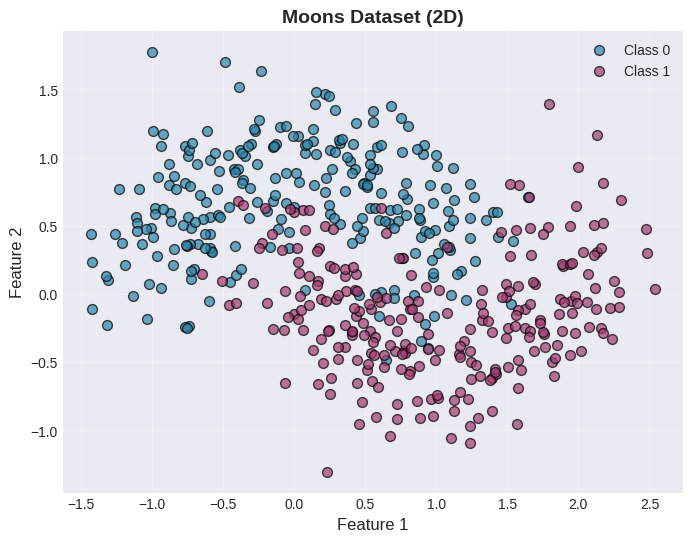

Dataset shape: (500, 2)
Class distribution: [250 250]


In [89]:
# Generate dataset (2D)
X_2d, y_binary = make_moons(n_samples=500, noise=0.3, random_state=4)

# Visualize 2D data
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[y_binary==0, 0], X_2d[y_binary==0, 1],
           c='#2E86AB', s=50, alpha=0.7, edgecolors='k', label='Class 0')
plt.scatter(X_2d[y_binary==1, 0], X_2d[y_binary==1, 1],
           c='#A23B72', s=50, alpha=0.7, edgecolors='k', label='Class 1')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Moons Dataset (2D)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Dataset shape: {X_2d.shape}")
print(f"Class distribution: {np.bincount(y_binary)}")

In [90]:
# Add extra dimensions to make it high-dimensional
# This simulates real-world scenarios with many features
n_extra_dims = 48
X_binary = np.hstack([X_2d, np.random.randn(500, n_extra_dims)])

print(f"High-dimensional dataset shape: {X_binary.shape}")
print(f"Total features: {X_binary.shape[1]} (2 informative + {n_extra_dims} noise)")

High-dimensional dataset shape: (500, 50)
Total features: 50 (2 informative + 48 noise)


In [91]:
# Split into train and test sets
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42, stratify=y_binary)

print(f"Training set: {X_train_bin.shape}")
print(f"Test set: {X_test_bin.shape}")
print(f"Training class distribution: {np.bincount(y_train_bin)}")
print(f"Test class distribution: {np.bincount(y_test_bin)}")

Training set: (350, 50)
Test set: (150, 50)
Training class distribution: [175 175]
Test class distribution: [75 75]


### Train Binary Classifier

In [92]:
# Train the classifier
model_binary, losses_binary = fit_dkgp_classifier(
    X_train_bin,
    y_train_bin,
    num_classes=2,
    feature_dim = 2,
    extractor_type = 'fc',    # Fully connected extractor
    num_epochs=2000,          # Training iterations
    verbose=False
)

### Make Predictions

In [93]:
# Predict class labels
y_pred_bin = predict_classifier(model_binary, X_test_bin)

# Predict class probabilities
y_proba_bin = predict_classifier(model_binary, X_test_bin, return_proba=True)

print(f"Predictions shape: {y_pred_bin.shape}")
print(f"Probabilities shape: {y_proba_bin.shape}")
print(f"\nFirst 5 predictions:")
print(f"  True:  {y_test_bin[:5]}")
print(f"  Pred:  {y_pred_bin[:5]}")
print(f"  Prob Class 0: {y_proba_bin[:5, 0]}")
print(f"  Prob Class 1: {y_proba_bin[:5, 1]}")

Predictions shape: (150,)
Probabilities shape: (150, 2)

First 5 predictions:
  True:  [1 1 0 0 1]
  Pred:  [1 0 1 1 1]
  Prob Class 0: [0.03176278 0.97508234 0.02282667 0.3418882  0.1279208 ]
  Prob Class 1: [0.9682372  0.02491763 0.9771733  0.6581118  0.8720792 ]


### Visualize Results

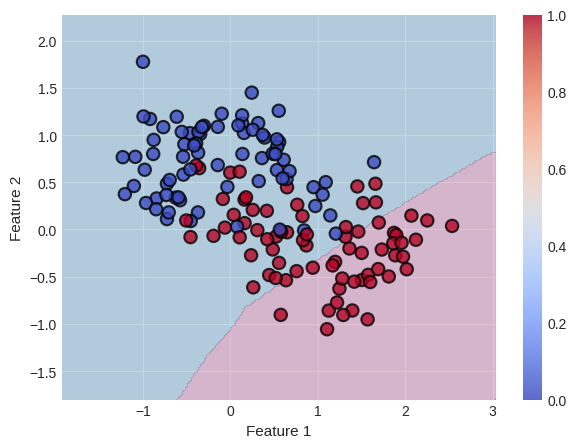

In [94]:
fig, ax = plt.subplots(figsize=(7, 5))

# 1. Decision boundary (2D projection)
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
mesh_2d = np.c_[xx.ravel(), yy.ravel()]
mesh_high = np.hstack([mesh_2d, np.zeros((len(mesh_2d), n_extra_dims))])
Z = predict_classifier(model_binary, mesh_high)
Z = Z.reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.3, levels=1, colors=['#2E86AB', '#A23B72'])
scatter = ax.scatter(X_test_bin[:, 0], X_test_bin[:, 1],
                            c=y_test_bin, s=80, edgecolors='k',
                            linewidth=1.5, cmap='coolwarm', alpha=0.8)
ax.set_xlabel('Feature 1', fontsize=11)
ax.set_ylabel('Feature 2', fontsize=11)
plt.colorbar(scatter, ax=ax)
plt.show()

---
### Active Learning Loop with Uncertainty Sampling

Active learning iteratively selects the most informative unlabeled points to label next, aiming to maximize classification accuracy with fewer labels.

**Acquisition function — Predictive Entropy:**

$$H[y \mid \mathbf{x}] = -\sum_c p(y=c \mid \mathbf{x})\,\log\,p(y=c \mid \mathbf{x})$$

Points with the highest entropy are the most uncertain, and are queried first.

In [104]:
def entropy_acquisition(model, X_pool):
    """
    Entropy acquisition function.
    Returns H[y|x] = -sum_c p_c * log(p_c) for every point in X_pool.
    Points with the highest entropy are the most uncertain.
    """
    proba = predict_classifier(model, X_pool, return_proba=True)
    proba = np.clip(proba, 1e-10, 1.0)
    return -np.sum(proba * np.log(proba), axis=1)


def margin_acquisition(model, X_pool):
    """
    Margin acquisition function.
    Returns the negative margin (top-1 prob minus top-2 prob).
    Smallest margin => highest score => selected first.
    """
    proba = predict_classifier(model, X_pool, return_proba=True)
    sorted_p = np.sort(proba, axis=1)[:, ::-1]
    return -(sorted_p[:, 0] - sorted_p[:, 1])


print("Acquisition functions ready: entropy_acquisition, margin_acquisition")

Acquisition functions ready: entropy_acquisition, margin_acquisition


In [105]:
# Active Learning Setup
# Carve a small initial labeled set from the training pool; the rest stays unlabeled
np.random.seed(3)

n_initial   = 5   # initial labeled samples
n_iterations = 10  # active learning iterations
n_query      = 5   # samples queried per iteration

init_idx = np.random.choice(len(X_train_bin), n_initial, replace=False)
pool_idx = np.setdiff1d(np.arange(len(X_train_bin)), init_idx)

X_al_labeled = X_train_bin[init_idx].copy()
y_al_labeled = y_train_bin[init_idx].copy()
X_al_pool    = X_train_bin[pool_idx].copy()
y_al_pool    = y_train_bin[pool_idx].copy()

print(f"Initial labeled set : {len(X_al_labeled)} samples")
print(f"Unlabeled pool      : {len(X_al_pool)} samples")
print(f"Test set            : {len(X_test_bin)} samples")

Initial labeled set : 5 samples
Unlabeled pool      : 345 samples
Test set            : 150 samples


In [106]:
# Iterative Active Learning Loop (entropy acquisition)
al_accuracies  = []
al_n_labeled   = []
X_queried      = []   # points selected by acquisition function each iteration
y_queried      = []
iter_queried   = []   # iteration index for each queried point (used for coloring)

X_cur_labeled = X_al_labeled.copy()
y_cur_labeled = y_al_labeled.copy()
X_cur_pool    = X_al_pool.copy()
y_cur_pool    = y_al_pool.copy()

for iteration in range(n_iterations + 1):
    # ── Train on current labeled set ──────────────────────────────────────
    model_al, _ = fit_dkgp_classifier(
        X_cur_labeled, y_cur_labeled,
        num_classes=2,
        feature_dim = 2,
        extractor_type='fc',
        num_epochs=1000,
        verbose=False)

    # ── Evaluate on held-out test set ─────────────────────────────────────
    y_pred_al = predict_classifier(model_al, X_test_bin)
    acc = precision_score(y_test_bin, y_pred_al)
    print(f"Iteration {iteration}: Precision = {acc:.4f}")
    al_accuracies.append(acc)
    al_n_labeled.append(len(X_cur_labeled))

    if len(X_cur_pool) == 0 or iteration == n_iterations:
        break

    # ── Acquisition: pick the n_query most uncertain pool points ──────────
    scores    = entropy_acquisition(model_al, X_cur_pool)
    query_idx = np.argsort(scores)[-n_query:]

    # Track queried points for later visualization
    X_queried.append(X_cur_pool[query_idx])
    y_queried.append(y_cur_pool[query_idx])
    iter_queried.extend([iteration] * len(query_idx))

    X_cur_labeled = np.vstack([X_cur_labeled, X_cur_pool[query_idx]])
    y_cur_labeled = np.concatenate([y_cur_labeled, y_cur_pool[query_idx]])
    X_cur_pool    = np.delete(X_cur_pool, query_idx, axis=0)
    y_cur_pool    = np.delete(y_cur_pool, query_idx)

# Stack all queried points
X_queried    = np.vstack(X_queried)
y_queried    = np.concatenate(y_queried)
iter_queried = np.array(iter_queried)


Iteration 0: Precision = 0.3919
Iteration 1: Precision = 0.5192
Iteration 2: Precision = 0.5385
Iteration 3: Precision = 0.5059
Iteration 4: Precision = 0.5902
Iteration 5: Precision = 0.5526
Iteration 6: Precision = 0.4459
Iteration 7: Precision = 0.5342
Iteration 8: Precision = 0.5244
Iteration 9: Precision = 0.5741
Iteration 10: Precision = 0.5325


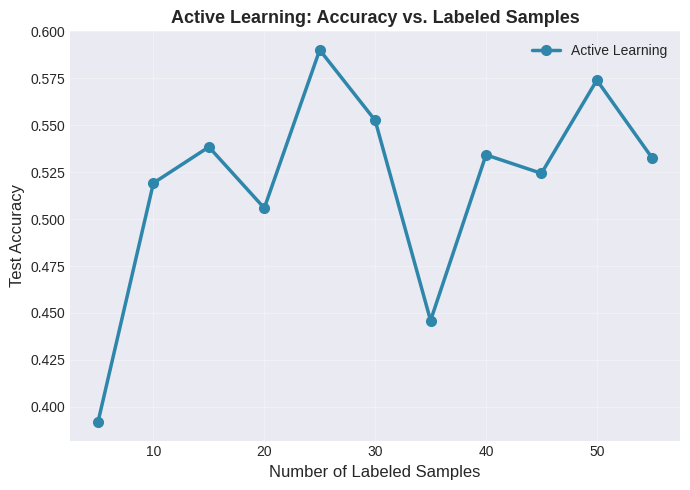

In [107]:
# Visualize Active Learning Results
fig, ax = plt.subplots(figsize=(7, 5))

# ── Left: accuracy curve vs. number of labeled samples ───────────────────
ax.plot(al_n_labeled, al_accuracies, 'o-',
             color='#2E86AB', linewidth=2.5, markersize=7, label='Active Learning')
ax.set_xlabel('Number of Labeled Samples', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Active Learning: Accuracy vs. Labeled Samples',
                  fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

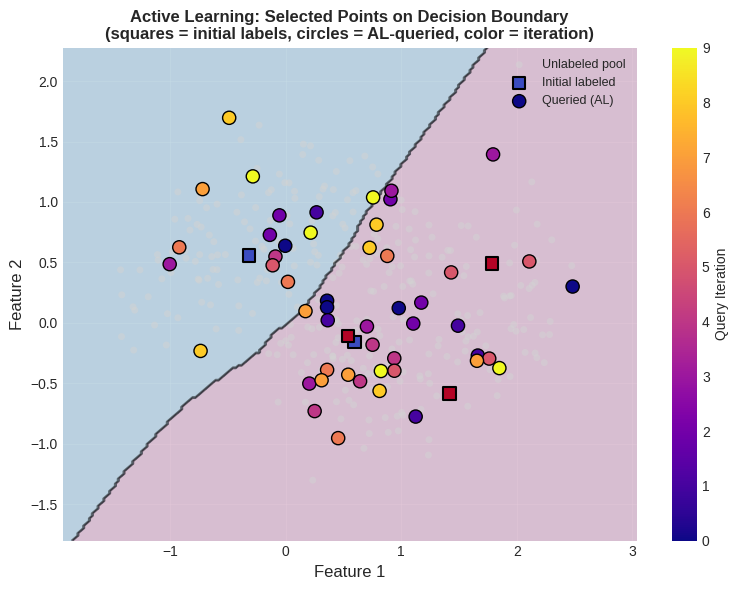

In [108]:
# Decision boundary map with actively selected points overlaid
fig, ax = plt.subplots(figsize=(8, 6))

# ── Decision boundary from final active learning model ────────────────────
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
mesh_2d  = np.c_[xx.ravel(), yy.ravel()]
mesh_high = np.hstack([mesh_2d, np.zeros((len(mesh_2d), n_extra_dims))])
Z = predict_classifier(model_al, mesh_high).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.25, levels=1, colors=['#2E86AB', '#A23B72'])
ax.contour(xx, yy, Z, levels=1, colors='k', linewidths=1.2, alpha=0.5)

# ── Remaining unlabeled pool (grey, background) ───────────────────────────
ax.scatter(X_cur_pool[:, 0], X_cur_pool[:, 1],
           c='lightgrey', s=25, alpha=0.5, edgecolors='none', label='Unlabeled pool')

# ── Initial labeled set (black outline squares) ───────────────────────────
ax.scatter(X_al_labeled[:, 0], X_al_labeled[:, 1],
           c=y_al_labeled, cmap='coolwarm', s=80, marker='s',
           edgecolors='k', linewidths=1.5, zorder=4, label='Initial labeled')

# ── Actively queried points (colored by iteration) ────────────────────────
sc = ax.scatter(X_queried[:, 0], X_queried[:, 1],
                c=iter_queried, cmap='plasma', s=90, marker='o',
                edgecolors='k', linewidths=1.0, zorder=5, label='Queried (AL)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Query Iteration', fontsize=10)

ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('Active Learning: Selected Points on Decision Boundary\n'
             '(squares = initial labels, circles = AL-queried, color = iteration)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()